# Discriminative Differentiable Dynamic Time Warping

In [ ]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
sensors_df, target_df = rf_preprocessor.read_data()
bend_cols = [col for col in sensors_df.columns if "BEND" in col or "Experiment" in col]
X = rf_preprocessor.group_and_pad(sensors_df[bend_cols], group_col="Experiment_ID")[80,::40,4:5]
Y = rf_preprocessor.group_and_pad(target_df, group_col="Experiment_ID")[80,:,1:2]
X.shape, Y.shape

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# -------------------------------
# 1. Create dummy training data
# -------------------------------
torch.manual_seed(0)
X_train = torch.randn(100, 10)
y_train = (X_train.sum(dim=1) > 0).float()

X_test = torch.randn(1, 10)
y_test = (X_test.sum(dim=1) > 0).float()

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)

# -------------------------------
# 2. Simple model
# -------------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

model = SimpleMLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# -------------------------------
# 3. Train the model
# -------------------------------
for epoch in range(50):
    for x, y in train_loader:
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y.unsqueeze(1))
        loss.backward()
        optimizer.step()

# -------------------------------
# 4. Compute gradient of test sample
# -------------------------------
model.eval()
optimizer.zero_grad()
test_pred = model(X_test)
test_loss = criterion(test_pred, y_test.unsqueeze(1))
test_loss.backward()

test_grads = [p.grad.clone().flatten() for p in model.parameters() if p.grad is not None]
test_grad_vector = torch.cat(test_grads)

# -------------------------------
# 5. Compute gradient similarity with each training sample
# -------------------------------
influence_scores = []

for i, (x, y) in enumerate(train_loader):
    optimizer.zero_grad()
    pred = model(x)
    loss = criterion(pred, y.unsqueeze(1))
    loss.backward()
    train_grads = [p.grad.clone().flatten() for p in model.parameters() if p.grad is not None]
    train_grad_vector = torch.cat(train_grads)

    # Cosine similarity between gradients
    sim = torch.cosine_similarity(train_grad_vector, test_grad_vector, dim=0)
    influence_scores.append(sim.item())

# -------------------------------
# 6. Rank training samples by influence
# -------------------------------
influence_scores = torch.tensor(influence_scores)
topk = torch.topk(influence_scores, k=5)

print("\nTop 5 most influential training samples for this test example:")
for idx, score in zip(topk.indices, topk.values):
    print(f"Sample {idx.item()} | Influence Score: {score.item():.4f}")



Top 5 most influential training samples for this test example:
Sample 83 | Influence Score: 0.0000
Sample 13 | Influence Score: 0.0000
Sample 95 | Influence Score: 0.0000
Sample 67 | Influence Score: 0.0000
Sample 49 | Influence Score: 0.0000


((44, 1), (47, 1))

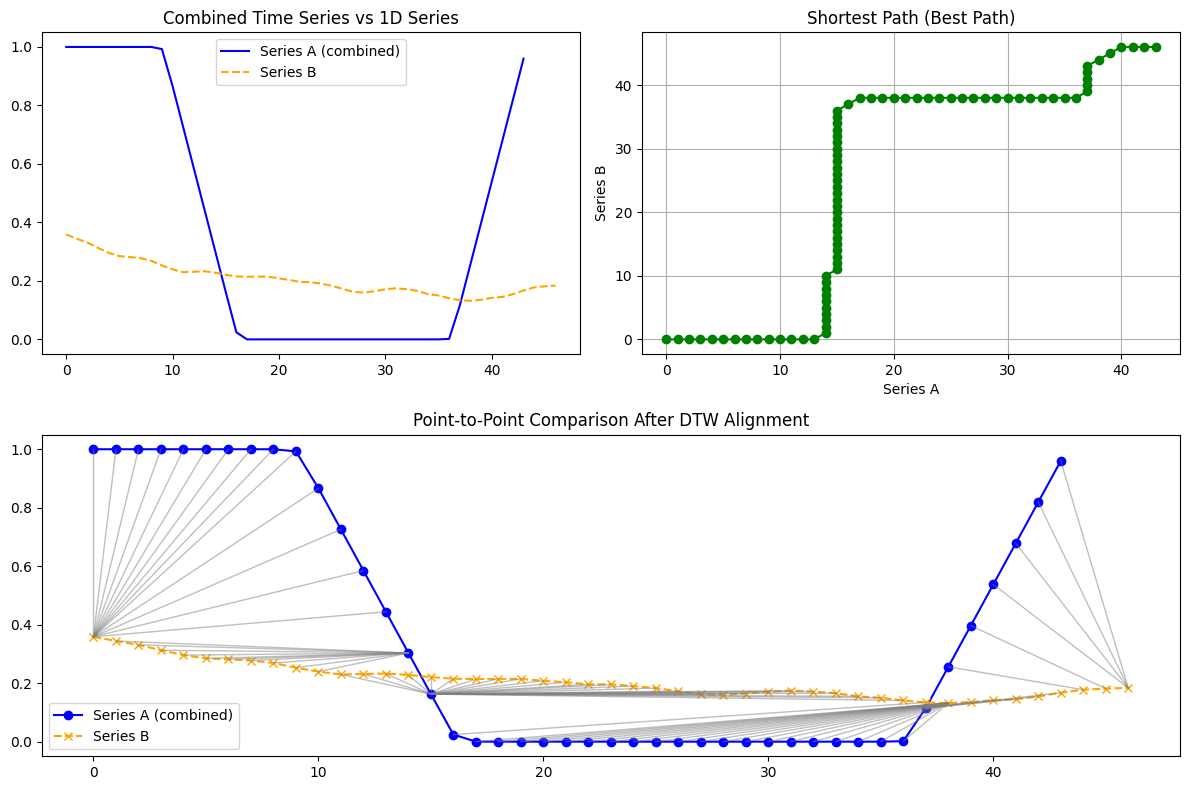

,Metric,Value,Description
0,DTW Similarity Score,0.030854,Lower scores indicate greater similarity betwe...


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from dtaidistance import dtw
import pandas as pd

# Multivariate series (100 timesteps, 3 features)
np.random.seed(0)
time_series_a = X
# 1D series (100 timesteps)
time_series_b = np.mean(Y, axis=1)

# Reduce multivariate series to 1D (average across features)
time_series_a_1d = np.mean(time_series_a, axis=1)

# Compute DTW
distance, paths = dtw.warping_paths(time_series_a_1d, time_series_b, use_c=False)
best_path = dtw.best_path(paths)
similarity_score = distance / len(best_path)

# Plotting
plt.figure(figsize=(12, 8))

# Original Time Series
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(time_series_a_1d, label='Series A (combined)', color='blue')
ax1.plot(time_series_b, label='Series B', linestyle='--', color='orange')
ax1.set_title('Combined Time Series vs 1D Series')
ax1.legend()

# Shortest Path Plot
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(np.array(best_path)[:, 0], np.array(best_path)[:, 1], 'green', marker='o', linestyle='-')
ax2.set_title('Shortest Path (Best Path)')
ax2.set_xlabel('Series A')
ax2.set_ylabel('Series B')
ax2.grid(True)

# Point-to-Point Comparison
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.plot(time_series_a_1d, label='Series A (combined)', color='blue', marker='o')
ax3.plot(time_series_b, label='Series B', color='orange', marker='x', linestyle='--')
for a, b in best_path:
    ax3.plot([a, b], [time_series_a_1d[a], time_series_b[b]], color='grey', linestyle='-', linewidth=1, alpha=0.5)
ax3.set_title('Point-to-Point Comparison After DTW Alignment')
ax3.legend()

plt.tight_layout()
plt.show()

# Results
results_df = pd.DataFrame({
    'Metric': ['DTW Similarity Score'],
    'Value': [similarity_score],
    'Description': ["Lower scores indicate greater similarity between the time series."]
})
results_df
